# Load the images

In [2]:
import pennylane as qml
import numpy as np
from tensorflow.keras.datasets import mnist
from matplotlib import pyplot as plt
import pandas as pd
from IPython.display import display
from sklearn.decomposition import PCA


In [3]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train_ones = x_train[y_train == 2]
x_train_ones_32 = np.pad(x_train_ones, ((0, 0), (2, 2), (2, 2)), mode='constant', constant_values=0)
Image = x_train_ones_32[0]

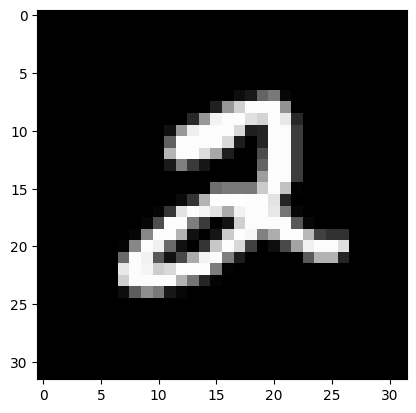

In [4]:
plt.imshow(Image, cmap='gray')
plt.show()

In [83]:
Image = Image / 255.0  # Normalize pixel values to [0, 1]

In [84]:
Eigenvalues, Eigenvectors = np.linalg.eigh(np.cov(Image))

In [85]:
U, S, Vh = np.linalg.svd(Image)


In [86]:
# Convert to DataFrame for better display
df_q = pd.DataFrame(Eigenvectors)

# Display as interactive table
display(df_q)

,0,1,2,3,4,5,6,7,8,9,...,22,23,24,25,26,27,28,29,30,31
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
6,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.147193,0.339053,-0.249816,-0.148153,0.181323,0.062985,-0.044806,-0.013558,-0.060088,-0.062384
8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.016461,0.199131,0.222552,-0.023932,0.211777,0.245707,-0.090985,0.159372,-0.226796,-0.258832
9,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.188687,-0.533567,0.008631,0.289689,0.131881,0.089541,0.172754,0.164184,-0.138196,-0.350219


In [87]:
df_l = pd.DataFrame(Eigenvalues)
display(df_l)

,0
0,0.000000
1,0.000000
2,0.000000
3,0.000000
4,0.000000
5,0.000000
6,0.000000
7,0.000000
8,0.000000
9,0.000000


In [33]:
df_s = pd.DataFrame(S)
display(df_s)

,0
0,4.638769e+00
1,3.874998e+00
2,3.287181e+00
3,2.550668e+00
4,1.611915e+00
5,9.583731e-01
6,5.873765e-01
7,5.483678e-01
8,4.403911e-01
9,3.370134e-01


In [88]:
Image_flat = Image  # shape: (height, width)

pca = PCA(n_components=10)
Image_pca = pca.fit_transform(Image_flat)

print("Transformed shape:", Image_pca.shape)
print("Explained variance ratio:", pca.explained_variance_ratio_)

Transformed shape: (32, 10)
Explained variance ratio: [0.42101584 0.23220963 0.13285563 0.10042267 0.05654543 0.02795339
 0.01373222 0.0041483  0.00310665 0.00269632]


In [89]:
Image_flat = Image.flatten()  # shape: (rows, cols)

In [90]:
image = Image.copy()

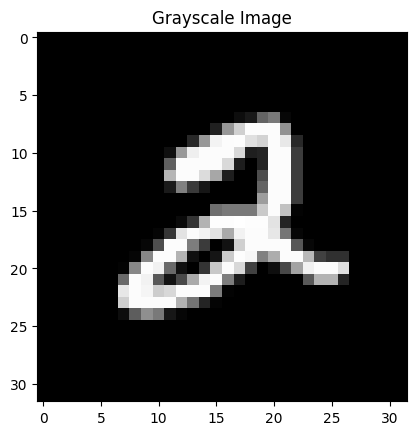

In [91]:
flattened_image = image.flatten()

plt.imshow(image, cmap='gray')
plt.title('Grayscale Image')
plt.show()


In [92]:
# Step 2: Computing the Covariance matrix
mean = np.mean(flattened_image)

normalized_image = flattened_image - mean
normalized_image_reshaped = normalized_image.reshape(image.shape)

cov_matrix = np.cov(normalized_image_reshaped, rowvar=False)

df_c = pd.DataFrame(cov_matrix)
display(df_c)

,0,1,2,3,4,5,6,7,8,9,...,22,23,24,25,26,27,28,29,30,31
0,1.789251e-33,1.789251e-33,1.789251e-33,1.789251e-33,1.789251e-33,1.789251e-33,1.789251e-33,3.727606e-34,1.789251e-33,3.976113e-34,...,8.697748e-35,8.697748e-34,8.231797e-34,7.175642e-34,1.764400e-33,1.789251e-33,1.789251e-33,1.789251e-33,1.789251e-33,1.789251e-33
1,1.789251e-33,1.789251e-33,1.789251e-33,1.789251e-33,1.789251e-33,1.789251e-33,1.789251e-33,3.727606e-34,1.789251e-33,3.976113e-34,...,8.697748e-35,8.697748e-34,8.231797e-34,7.175642e-34,1.764400e-33,1.789251e-33,1.789251e-33,1.789251e-33,1.789251e-33,1.789251e-33
2,1.789251e-33,1.789251e-33,1.789251e-33,1.789251e-33,1.789251e-33,1.789251e-33,1.789251e-33,3.727606e-34,1.789251e-33,3.976113e-34,...,8.697748e-35,8.697748e-34,8.231797e-34,7.175642e-34,1.764400e-33,1.789251e-33,1.789251e-33,1.789251e-33,1.789251e-33,1.789251e-33
3,1.789251e-33,1.789251e-33,1.789251e-33,1.789251e-33,1.789251e-33,1.789251e-33,1.789251e-33,3.727606e-34,1.789251e-33,3.976113e-34,...,8.697748e-35,8.697748e-34,8.231797e-34,7.175642e-34,1.764400e-33,1.789251e-33,1.789251e-33,1.789251e-33,1.789251e-33,1.789251e-33
4,1.789251e-33,1.789251e-33,1.789251e-33,1.789251e-33,1.789251e-33,1.789251e-33,1.789251e-33,3.727606e-34,1.789251e-33,3.976113e-34,...,8.697748e-35,8.697748e-34,8.231797e-34,7.175642e-34,1.764400e-33,1.789251e-33,1.789251e-33,1.789251e-33,1.789251e-33,1.789251e-33
5,1.789251e-33,1.789251e-33,1.789251e-33,1.789251e-33,1.789251e-33,1.789251e-33,1.789251e-33,3.727606e-34,1.789251e-33,3.976113e-34,...,8.697748e-35,8.697748e-34,8.231797e-34,7.175642e-34,1.764400e-33,1.789251e-33,1.789251e-33,1.789251e-33,1.789251e-33,1.789251e-33
6,1.789251e-33,1.789251e-33,1.789251e-33,1.789251e-33,1.789251e-33,1.789251e-33,1.789251e-33,3.727606e-34,1.789251e-33,3.976113e-34,...,8.697748e-35,8.697748e-34,8.231797e-34,7.175642e-34,1.764400e-33,1.789251e-33,1.789251e-33,1.789251e-33,1.789251e-33,1.789251e-33
7,3.727606e-34,3.727606e-34,3.727606e-34,3.727606e-34,3.727606e-34,3.727606e-34,3.727606e-34,4.844190e-02,6.010539e-02,5.680760e-02,...,-7.132198e-03,4.796077e-04,5.435409e-03,5.582732e-03,-4.186200e-04,3.727606e-34,3.727606e-34,3.727606e-34,3.727606e-34,3.727606e-34
8,1.789251e-33,1.789251e-33,1.789251e-33,1.789251e-33,1.789251e-33,1.789251e-33,1.789251e-33,6.010539e-02,9.279502e-02,9.675122e-02,...,-1.438560e-03,1.984624e-02,3.202497e-02,3.224371e-02,1.504995e-02,1.789251e-33,1.789251e-33,1.789251e-33,1.789251e-33,1.789251e-33
9,3.976113e-34,3.976113e-34,3.976113e-34,3.976113e-34,3.976113e-34,3.976113e-34,3.976113e-34,5.680760e-02,9.675122e-02,1.158394e-01,...,2.069227e-02,4.285866e-02,4.768975e-02,4.688725e-02,2.949401e-02,3.976113e-34,3.976113e-34,3.976113e-34,3.976113e-34,3.976113e-34


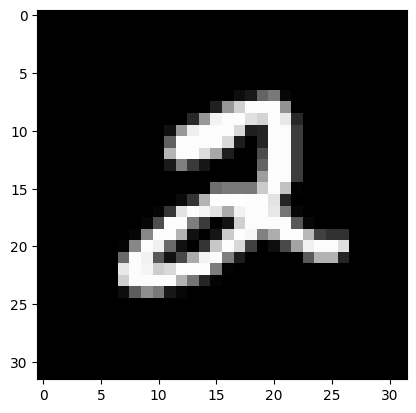

In [93]:
plt.imshow(normalized_image_reshaped, cmap='gray')

In [ ]:
# Step 3: Find the Eigenvalues and Eigenvectors
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

# Step 4: Select the PCA with the desired variance
sorted_indices = np.argsort(eigenvalues)[::-1]
sorted_eigenvalues = eigenvalues[sorted_indices]
sorted_eigenvectors = eigenvectors[:, sorted_indices]

Eigenvalues:
 [ 1.78925105e-33+0.00000000e+00j  9.49467388e-01+0.00000000e+00j
  5.23675003e-01+0.00000000e+00j  2.99613635e-01+0.00000000e+00j
  2.26471402e-01+0.00000000e+00j  1.27520235e-01+0.00000000e+00j
  6.30399940e-02+0.00000000e+00j  3.09686666e-02+0.00000000e+00j
  9.35517506e-03+0.00000000e+00j  7.00605732e-03+0.00000000e+00j
  6.08068628e-03+0.00000000e+00j  4.71473855e-03+0.00000000e+00j
  3.28686726e-03+0.00000000e+00j  1.91293183e-03+0.00000000e+00j
  8.98702901e-04+0.00000000e+00j  7.68589740e-04+0.00000000e+00j
  3.76153015e-04+0.00000000e+00j  2.44782567e-05+0.00000000e+00j
  1.37571943e-06+0.00000000e+00j  1.11831426e-17+3.89372811e-17j
  1.11831426e-17-3.89372811e-17j -3.27037068e-17+0.00000000e+00j
 -3.81608223e-18+1.00565252e-17j -3.81608223e-18-1.00565252e-17j
  7.30377684e-18+2.52592451e-18j  7.30377684e-18-2.52592451e-18j
  2.22298374e-19+2.73540908e-18j  2.22298374e-19-2.73540908e-18j
 -9.31118176e-22+5.60615795e-22j -9.31118176e-22-5.60615795e-22j
 -2.1957538

In [95]:
# Select top k principal components
k = 10  # You can change this value
top_k_eigenvectors = sorted_eigenvectors[:, :k]
top_k_eigenvalues = sorted_eigenvalues[:k]

In [96]:
projected_image = np.dot(normalized_image_reshaped, top_k_eigenvectors)

In [97]:
projected_image.shape

(32, 10)

In [98]:
reconstructed_image = np.dot(projected_image, top_k_eigenvectors.T) + mean

In [99]:
reconstructed_image.shape

(32, 32)

In [100]:
df_r = pd.DataFrame(reconstructed_image)
display(df_r)

,0,1,2,3,4,5,6,7,8,9,...,22,23,24,25,26,27,28,29,30,31
0,0.113362+0.000000j,0.113362+0.000000j,0.113362+0.000000j,0.113362+0.000000j,0.113362+0.000000j,0.113362+0.000000j,0.113362+0.000000j,0.069790+0.000000j,-0.000737+0.000000j,-0.034303+0.000000j,...,0.035192+0.000000j,0.014576+0.000000j,-0.003853+0.000000j,-0.003012+0.000000j,0.040333+0.000000j,0.113362+0.000000j,0.113362+0.000000j,0.113362+0.000000j,0.113362+0.000000j,0.113362+0.000000j
1,0.113362+0.000000j,0.113362+0.000000j,0.113362+0.000000j,0.113362+0.000000j,0.113362+0.000000j,0.113362+0.000000j,0.113362+0.000000j,0.069790+0.000000j,-0.000737+0.000000j,-0.034303+0.000000j,...,0.035192+0.000000j,0.014576+0.000000j,-0.003853+0.000000j,-0.003012+0.000000j,0.040333+0.000000j,0.113362+0.000000j,0.113362+0.000000j,0.113362+0.000000j,0.113362+0.000000j,0.113362+0.000000j
2,0.113362+0.000000j,0.113362+0.000000j,0.113362+0.000000j,0.113362+0.000000j,0.113362+0.000000j,0.113362+0.000000j,0.113362+0.000000j,0.069790+0.000000j,-0.000737+0.000000j,-0.034303+0.000000j,...,0.035192+0.000000j,0.014576+0.000000j,-0.003853+0.000000j,-0.003012+0.000000j,0.040333+0.000000j,0.113362+0.000000j,0.113362+0.000000j,0.113362+0.000000j,0.113362+0.000000j,0.113362+0.000000j
3,0.113362+0.000000j,0.113362+0.000000j,0.113362+0.000000j,0.113362+0.000000j,0.113362+0.000000j,0.113362+0.000000j,0.113362+0.000000j,0.069790+0.000000j,-0.000737+0.000000j,-0.034303+0.000000j,...,0.035192+0.000000j,0.014576+0.000000j,-0.003853+0.000000j,-0.003012+0.000000j,0.040333+0.000000j,0.113362+0.000000j,0.113362+0.000000j,0.113362+0.000000j,0.113362+0.000000j,0.113362+0.000000j
4,0.113362+0.000000j,0.113362+0.000000j,0.113362+0.000000j,0.113362+0.000000j,0.113362+0.000000j,0.113362+0.000000j,0.113362+0.000000j,0.069790+0.000000j,-0.000737+0.000000j,-0.034303+0.000000j,...,0.035192+0.000000j,0.014576+0.000000j,-0.003853+0.000000j,-0.003012+0.000000j,0.040333+0.000000j,0.113362+0.000000j,0.113362+0.000000j,0.113362+0.000000j,0.113362+0.000000j,0.113362+0.000000j
5,0.113362+0.000000j,0.113362+0.000000j,0.113362+0.000000j,0.113362+0.000000j,0.113362+0.000000j,0.113362+0.000000j,0.113362+0.000000j,0.069790+0.000000j,-0.000737+0.000000j,-0.034303+0.000000j,...,0.035192+0.000000j,0.014576+0.000000j,-0.003853+0.000000j,-0.003012+0.000000j,0.040333+0.000000j,0.113362+0.000000j,0.113362+0.000000j,0.113362+0.000000j,0.113362+0.000000j,0.113362+0.000000j
6,0.113362+0.000000j,0.113362+0.000000j,0.113362+0.000000j,0.113362+0.000000j,0.113362+0.000000j,0.113362+0.000000j,0.113362+0.000000j,0.069790+0.000000j,-0.000737+0.000000j,-0.034303+0.000000j,...,0.035192+0.000000j,0.014576+0.000000j,-0.003853+0.000000j,-0.003012+0.000000j,0.040333+0.000000j,0.113362+0.000000j,0.113362+0.000000j,0.113362+0.000000j,0.113362+0.000000j,0.113362+0.000000j
7,0.113362+0.000000j,0.113362+0.000000j,0.113362+0.000000j,0.113362+0.000000j,0.113362+0.000000j,0.113362+0.000000j,0.113362+0.000000j,0.055746+0.000000j,0.004646+0.000000j,-0.023332+0.000000j,...,-0.011725+0.000000j,-0.001529+0.000000j,-0.007491+0.000000j,-0.002878+0.000000j,0.063427+0.000000j,0.113362+0.000000j,0.113362+0.000000j,0.113362+0.000000j,0.113362+0.000000j,0.113362+0.000000j
8,0.113362+0.000000j,0.113362+0.000000j,0.113362+0.000000j,0.113362+0.000000j,0.113362+0.000000j,0.113362+0.000000j,0.113362+0.000000j,0.048223+0.000000j,-0.015552+0.000000j,-0.032610+0.000000j,...,0.076395+0.000000j,0.006494+0.000000j,-0.025051+0.000000j,-0.024322+0.000000j,0.033906+0.000000j,0.113362+0.000000j,0.113362+0.000000j,0.113362+0.000000j,0.113362+0.000000j,0.113362+0.000000j
9,0.113362+0.000000j,0.113362+0.000000j,0.113362+0.000000j,0.113362+0.000000j,0.113362+0.000000j,0.113362+0.000000j,0.113362+0.000000j,0.090491+0.000000j,0.003198+0.000000j,-0.047628+0.000000j,...,0.198419+0.000000j,0.035024+0.000000j,0.011901+0.000000j,0.007615+0.000000j,0.003858+0.000000j,0.113362+0.000000j,0.113362+0.000000j,0.113362+0.000000j,0.113362+0.000000j,0.113362+0.000000j


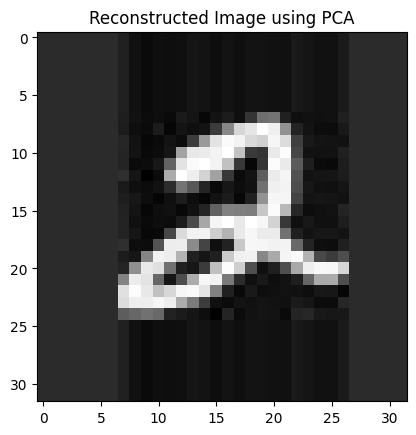

In [101]:
plt.imshow(np.real(reconstructed_image), cmap='gray')
plt.title('Reconstructed Image using PCA')
plt.show()

In [116]:
Img = np.zeros_like(image, dtype=complex)
for i in range(2):
    Img += sorted_eigenvalues[i]*np.outer(sorted_eigenvectors[:, i], sorted_eigenvectors[:, i].conj())

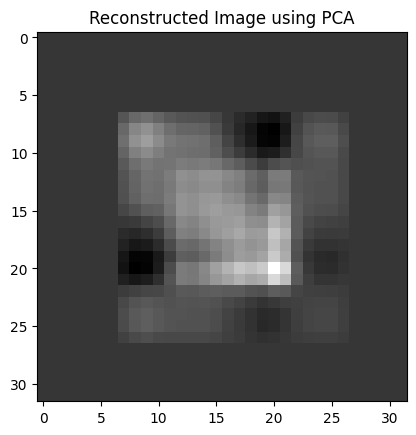

In [117]:
plt.imshow(np.real(Img), cmap='gray')
plt.title('Reconstructed Image using PCA')
plt.show()

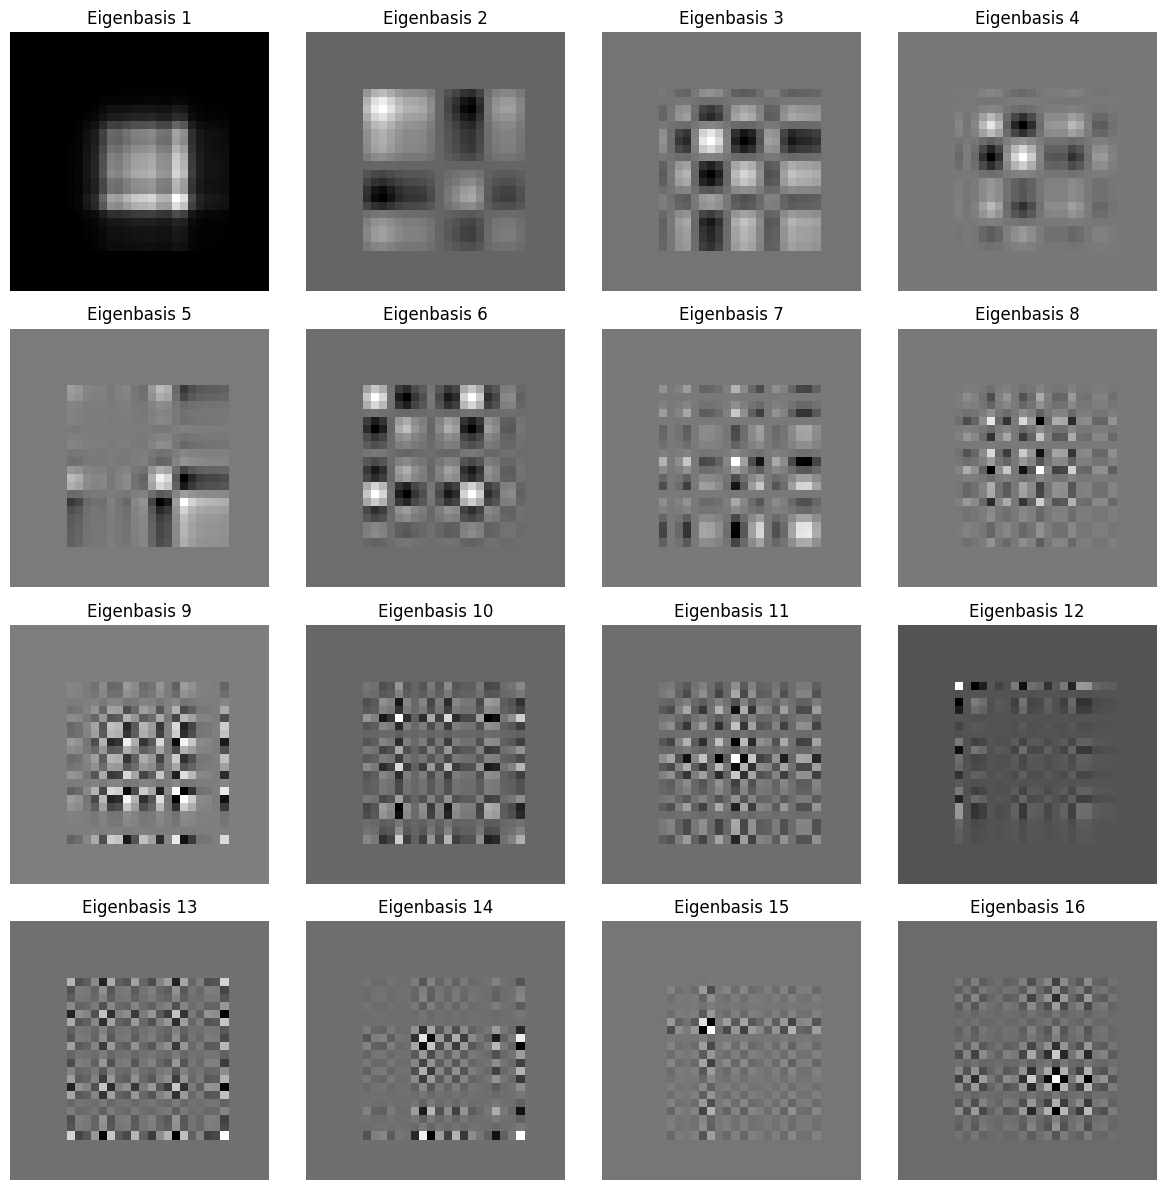

In [118]:
fig, axes = plt.subplots(4, 4, figsize=(12, 12))
for idx in range(16):
    basis_img = np.outer(sorted_eigenvectors[:, idx], sorted_eigenvectors[:, idx].conj())
    ax = axes[idx // 4, idx % 4]
    ax.imshow(np.real(basis_img), cmap='gray')
    ax.set_title(f'Eigenbasis {idx+1}')
    ax.axis('off')
plt.tight_layout()
plt.show()

### Images eigenvalues

In [5]:
Img = np.cov(Image)
eigenvalues, eigenvectors = np.linalg.eig(Img)

df_l = pd.DataFrame(eigenvalues)

display(df_l)

,0
0,66513.057361
1,28497.076231
2,17536.990782
3,14799.245344
4,8254.829199
5,4559.303074
6,1938.947336
7,609.404966
8,462.534091
9,397.983104


In [6]:
Img = np.cov(Image/255.0)
eigenvalues, eigenvectors = np.linalg.eig(Img)

df_l = pd.DataFrame(eigenvalues)

display(df_l)

,0
0,1.022884
1,0.438248
2,0.269696
3,0.227593
4,0.126949
5,0.070116
6,0.029818
7,0.009372
8,0.007113
9,0.006120


In [7]:
df_q = pd.DataFrame(eigenvectors)

display(df_q)

,0,1,2,3,4,5,6,7,8,9,...,22,23,24,25,26,27,28,29,30,31
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,0.062384,0.060088,0.013558,-0.044806,-0.062985,-0.181323,-0.148153,-0.249816,0.339053,0.147193,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,0.258832,0.226796,-0.159372,-0.090985,-0.245707,-0.211777,-0.023932,0.222552,0.199131,0.016461,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,0.350219,0.138196,-0.164184,0.172754,-0.089541,-0.131881,0.289689,0.008631,-0.533567,-0.188687,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
